In [2]:
%pip install openbb
%pip install pyarrow
%pip install numpy
%pip install pandas
%pip install scipy
%pip install joblib
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import optionsdata as od
from datetime import datetime
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from openbb import obb



In [4]:
failed = await od.fetch_options(["ZEB"], datetime(2024, 1, 1).date(), datetime(2025, 2, 18).date())
print(failed)

Failed to fetch options for ZEB on 2024-01-01: 
[Error] -> 1 validations error(s)
[Arg] provider -> input: tmx -> Input should be 'intrinio' or 'yfinance'
Failed to fetch options for ZEB on 2024-01-02: 
[Error] -> 1 validations error(s)
[Arg] provider -> input: tmx -> Input should be 'intrinio' or 'yfinance'
Failed to fetch options for ZEB on 2024-01-03: 
[Error] -> 1 validations error(s)
[Arg] provider -> input: tmx -> Input should be 'intrinio' or 'yfinance'
Failed to fetch options for ZEB on 2024-01-04: 
[Error] -> 1 validations error(s)
[Arg] provider -> input: tmx -> Input should be 'intrinio' or 'yfinance'
Failed to fetch options for ZEB on 2024-01-05: 
[Error] -> 1 validations error(s)
[Arg] provider -> input: tmx -> Input should be 'intrinio' or 'yfinance'
Failed to fetch options for ZEB on 2024-01-06: 
[Error] -> 1 validations error(s)
[Arg] provider -> input: tmx -> Input should be 'intrinio' or 'yfinance'
Failed to fetch options for ZEB on 2024-01-07: 
[Error] -> 1 validatio

In [5]:
df = pd.read_parquet('data/2024_TRI.parquet')
df[df["volume"] > 0]

,expiration,strike,option_type,underlying_symbol,underlying_price,contract_symbol,eod_date,dte,open_interest,volume,...,close_bid_size,close_ask,close_ask_size,prev_close,change,implied_volatility,transactions,total_value,settlement_price,Breakeven
query_date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,2024-02-16,185.0,call,TRI:CA,191.95,TRI 240216C185.00,2024-01-02,45,4,4,...,10,10.65,25,12.40,-1.90,0.20152,1,42.0,10.65,195.65
2024-01-01,2024-02-16,195.0,call,TRI:CA,191.95,TRI 240216C195.00,2024-01-02,45,5,5,...,35,4.05,25,4.90,-1.40,0.17577,1,17.0,4.05,199.05
2024-01-01,2024-03-15,200.0,call,TRI:CA,191.95,TRI 240315C200.00,2024-01-02,73,16,2,...,45,3.25,10,3.95,-1.25,0.16249,1,5.0,3.25,203.25
2024-01-01,2024-03-15,205.0,call,TRI:CA,191.95,TRI 240315C205.00,2024-01-02,73,21,1,...,55,1.80,20,2.30,-0.75,0.15905,1,1.0,1.80,206.80
2024-01-02,2024-02-16,185.0,call,TRI:CA,191.95,TRI 240216C185.00,2024-01-02,45,4,4,...,10,10.65,25,12.40,-1.90,0.20152,1,42.0,10.65,195.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-18,2025-03-21,230.0,put,TRI:CA,246.35,TRI 250321P230.00,2025-02-18,31,2,4,...,30,1.50,30,1.70,-0.05,0.23292,2,6.0,1.45,228.55
2025-02-18,2025-03-21,235.0,put,TRI:CA,246.35,TRI 250321P235.00,2025-02-18,31,5,2,...,20,2.25,20,2.50,-0.35,0.22716,1,4.0,2.25,232.75
2025-02-18,2025-03-21,260.0,call,TRI:CA,246.35,TRI 250321C260.00,2025-02-18,31,29,1,...,30,1.30,20,1.55,-0.55,0.17630,1,1.0,1.30,261.30


In [6]:
bmo = pd.read_parquet('data/2024_BMO.parquet')
bns = pd.read_parquet('data/2024_BNS.parquet')
ry = pd.read_parquet('data/2024_RY.parquet')
td = pd.read_parquet('data/2024_TD.parquet')
xiu = pd.read_parquet('data/2024_XIU.parquet')
zeb = pd.read_parquet('data/2024_ZEB.parquet')

In [7]:
dfs = [bmo, bns, ry, td, xiu, zeb]
merged = pd.concat(dfs)
merged

,expiration,strike,option_type,underlying_symbol,underlying_price,contract_symbol,eod_date,dte,open_interest,volume,...,close_bid_size,close_ask,close_ask_size,prev_close,change,implied_volatility,transactions,total_value,settlement_price,Breakeven
query_date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,2024-01-05,107.0,call,BMO:CA,130.49,BMO 240105C107.00,2024-01-02,3,0,0,...,46,24.10,15,24.30,0.0,1.27633,0,0.0,24.10,131.10
2024-01-01,2024-01-05,107.0,put,BMO:CA,130.49,BMO 240105P107.00,2024-01-02,3,0,0,...,0,0.05,31,0.05,0.0,0.90545,0,0.0,0.05,106.95
2024-01-01,2024-01-05,108.0,call,BMO:CA,130.49,BMO 240105C108.00,2024-01-02,3,0,0,...,46,23.10,15,23.30,0.0,1.22632,0,0.0,23.10,131.10
2024-01-01,2024-01-05,108.0,put,BMO:CA,130.49,BMO 240105P108.00,2024-01-02,3,0,0,...,0,0.05,31,0.05,0.0,0.86754,0,0.0,0.05,107.95
2024-01-01,2024-01-05,110.0,call,BMO:CA,130.49,BMO 240105C110.00,2024-01-02,3,0,0,...,46,21.10,15,21.30,0.0,1.12695,0,0.0,21.10,131.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-18,2028-03-17,54.0,put,ZEB:CA,42.19,ZEB 280317P54.00,2025-02-18,1123,0,0,...,30,13.30,10,13.50,0.0,0.07567,0,0.0,13.30,40.70
2025-02-18,2028-03-17,56.0,call,ZEB:CA,42.19,ZEB 280317C56.00,2025-02-18,1123,0,0,...,20,8.25,20,6.15,0.0,0.31820,0,0.0,8.25,64.25
2025-02-18,2028-03-17,56.0,put,ZEB:CA,42.19,ZEB 280317P56.00,2025-02-18,1123,0,0,...,20,15.10,10,15.20,0.0,0.07473,0,0.0,15.10,40.90


In [8]:
df = pd.read_parquet('data/2024_ALL.parquet')
print(merged.columns)


Index(['expiration', 'strike', 'option_type', 'underlying_symbol',
       'underlying_price', 'contract_symbol', 'eod_date', 'dte',
       'open_interest', 'volume', 'last_trade_price', 'open', 'high', 'low',
       'close_bid', 'close_bid_size', 'close_ask', 'close_ask_size',
       'prev_close', 'change', 'implied_volatility', 'transactions',
       'total_value', 'settlement_price', 'Breakeven'],
      dtype='object')


In [9]:
# Function to calculate delta (price change)
def calculate_delta(df):
    df['delta'] = df['close_bid'].diff()  # Or use 'close_ask' if needed
    return df

# Read the data files (you can adjust the paths if needed)
df = pd.read_parquet('data/2024_ALL.parquet')
dfs = [bmo, bns, ry, td, xiu, zeb]

# Merge the dataframes into one
merged = pd.concat(dfs)

# Filter out rows with volume <= 0 (as per your requirement)
merged = merged[merged["volume"] > 0]

# Apply delta calculation
merged = calculate_delta(merged)
# Check the column names in the dataframe
print(merged.columns)


# Check the first few rows of the merged dataframe with delta
print(merged.head())

Index(['expiration', 'strike', 'option_type', 'underlying_symbol',
       'underlying_price', 'contract_symbol', 'eod_date', 'dte',
       'open_interest', 'volume', 'last_trade_price', 'open', 'high', 'low',
       'close_bid', 'close_bid_size', 'close_ask', 'close_ask_size',
       'prev_close', 'change', 'implied_volatility', 'transactions',
       'total_value', 'settlement_price', 'Breakeven', 'delta'],
      dtype='object')
            expiration  strike option_type underlying_symbol  \
query_date                                                     
2024-01-01  2024-01-05   126.0         put            BMO:CA   
2024-01-01  2024-01-05   132.0        call            BMO:CA   
2024-01-01  2024-01-05   132.0         put            BMO:CA   
2024-01-01  2024-01-12   122.0         put            BMO:CA   
2024-01-01  2024-01-12   126.0         put            BMO:CA   

            underlying_price      contract_symbol    eod_date  dte  \
query_date                                     

count    149414.000000
mean          0.000013
std           6.228756
min        -119.500000
25%          -1.250000
50%          -0.040000
75%           0.920000
max         117.450000
Name: delta, dtype: float64
expiration            0
strike                0
option_type           0
underlying_symbol     0
underlying_price      0
contract_symbol       0
eod_date              0
dte                   0
open_interest         0
volume                0
last_trade_price      0
open                  0
high                  0
low                   0
close_bid             0
close_bid_size        0
close_ask             0
close_ask_size        0
prev_close            0
change                0
implied_volatility    0
transactions          0
total_value           0
settlement_price      0
Breakeven             0
delta                 1
dtype: int64


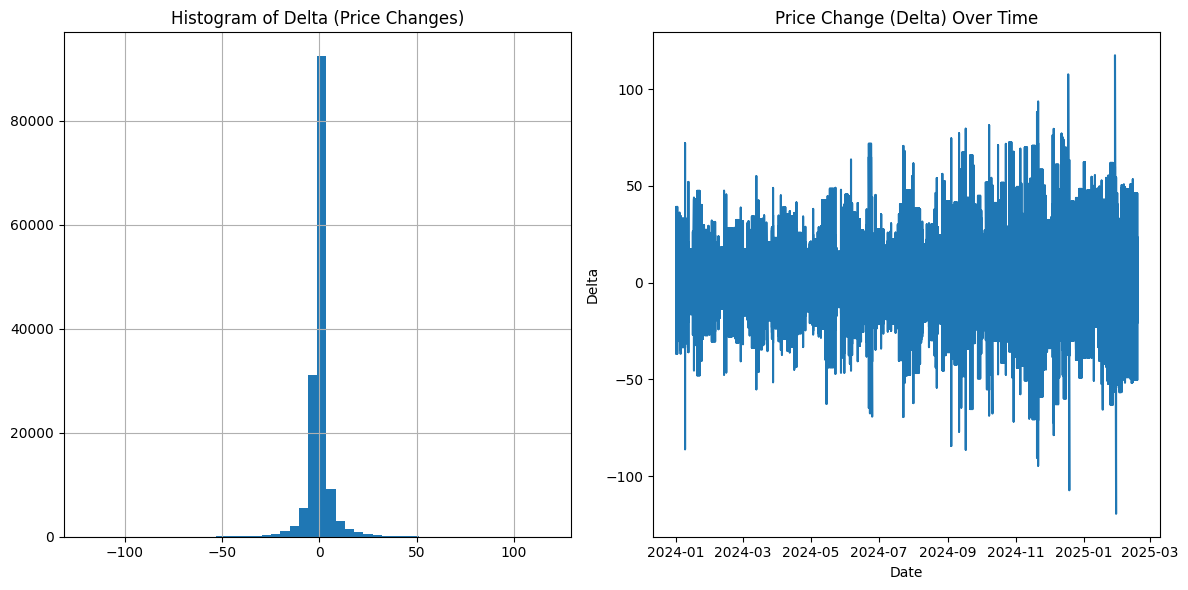

In [10]:
# Summary statistics of delta
print(merged['delta'].describe())

# Checking for missing values
print(merged.isnull().sum())

# Plotting a few basic graphs
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
merged['delta'].hist(bins=50)
plt.title('Histogram of Delta (Price Changes)')

plt.subplot(1, 2, 2)
merged['delta'].plot(kind='line', title='Price Change (Delta) Over Time')
plt.xlabel('Date')
plt.ylabel('Delta')

plt.tight_layout()
plt.show()


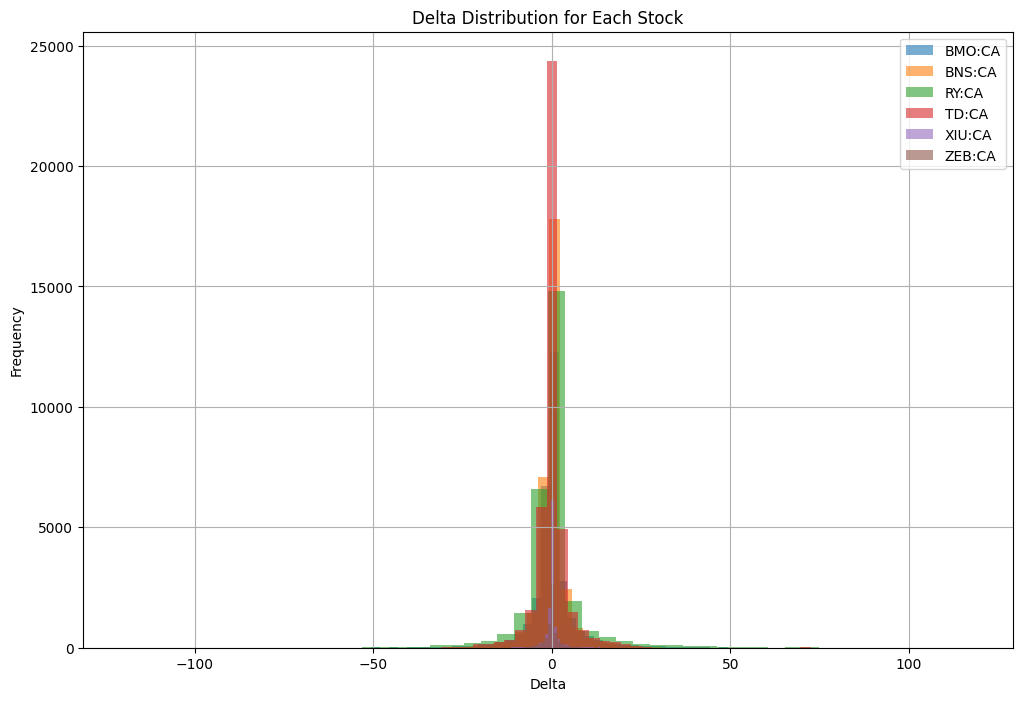

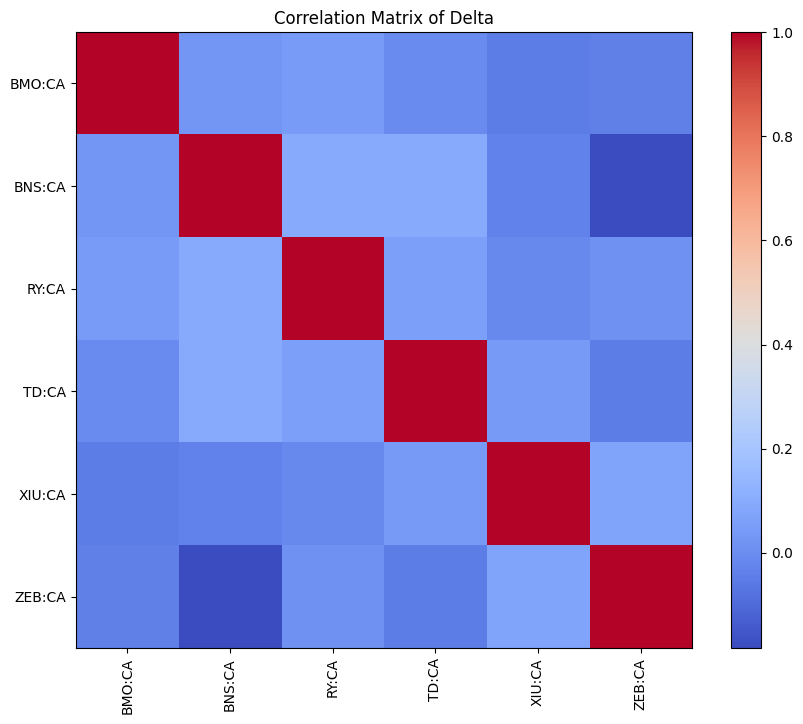

<Figure size 1200x600 with 0 Axes>

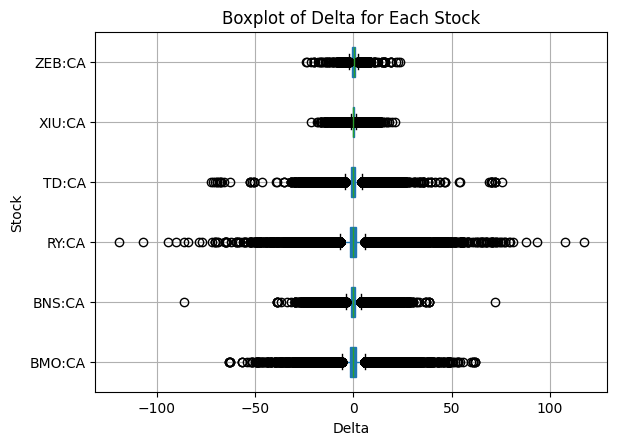

In [11]:
# Plotting delta distribution for each stock using 'underlying_symbol' instead of 'symbol'
plt.figure(figsize=(12, 8))

for stock in merged['underlying_symbol'].unique():
    stock_data = merged[merged['underlying_symbol'] == stock]
    stock_data['delta'].hist(label=stock, alpha=0.6, bins=50)

plt.legend()
plt.title('Delta Distribution for Each Stock')
plt.xlabel('Delta')
plt.ylabel('Frequency')
plt.show()


# Creating a pivot table for the delta of each stock using 'eod_date' instead of 'date'
pivot_delta = merged.pivot_table(values='delta', index='eod_date', columns='underlying_symbol')

# Plotting the correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = pivot_delta.corr()
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.title('Correlation Matrix of Delta')
plt.xticks(np.arange(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(np.arange(len(correlation_matrix.index)), correlation_matrix.index)
plt.show()

plt.figure(figsize=(12, 6))
merged.boxplot(column='delta', by='underlying_symbol', vert=False, patch_artist=True)
plt.title('Boxplot of Delta for Each Stock')
plt.suptitle('')
plt.xlabel('Delta')
plt.ylabel('Stock')
plt.show()



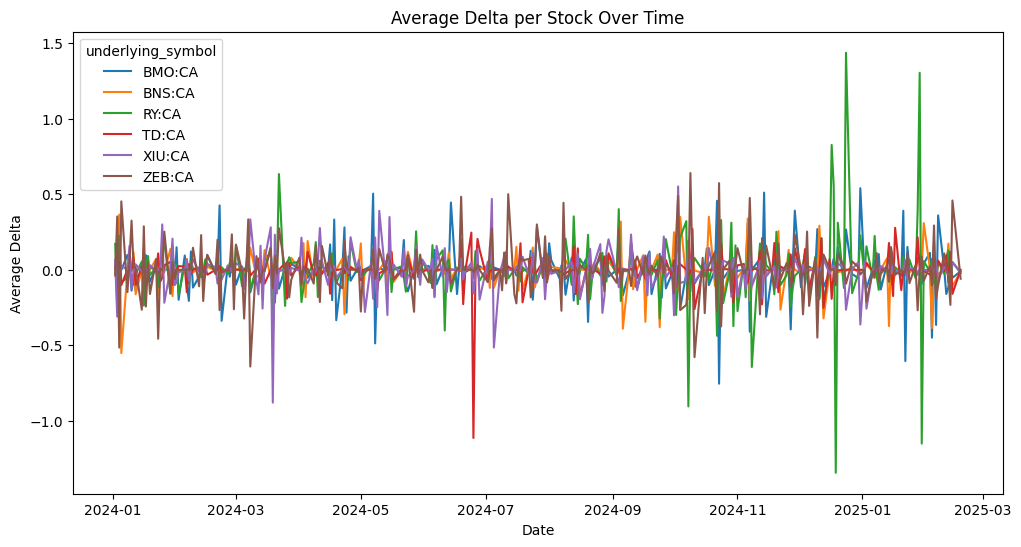

In [12]:
avg_delta_per_day = merged.groupby(['eod_date', 'underlying_symbol'])['delta'].mean().unstack()
avg_delta_per_day.plot(figsize=(12, 6), title='Average Delta per Stock Over Time')
plt.xlabel('Date')
plt.ylabel('Average Delta')
plt.show()


   underlying_price  strike     delta  delta_normalized
0            130.49   126.0  0.936297          0.936297
1            130.49   132.0  0.218701          0.218701
2            130.49   132.0  0.164105          0.164105
3            130.49   122.0  0.951813          0.951813
4            130.49   126.0  0.875727          0.875727


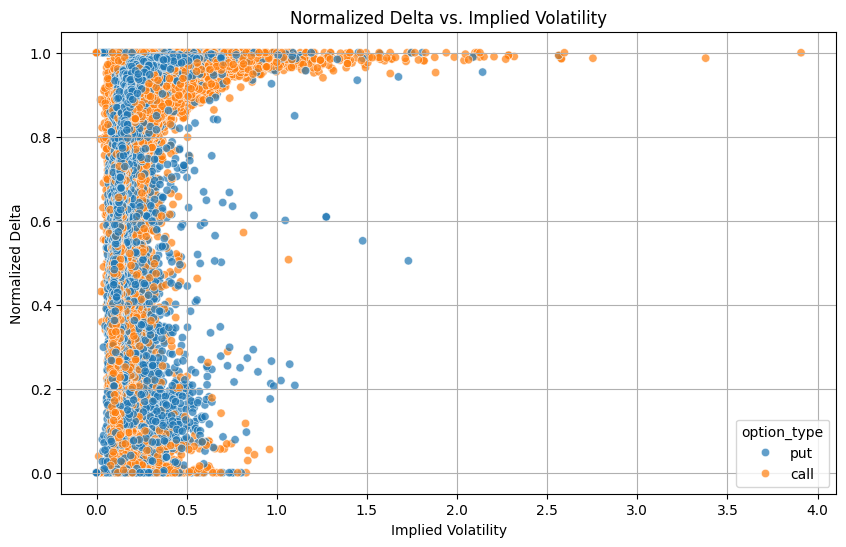

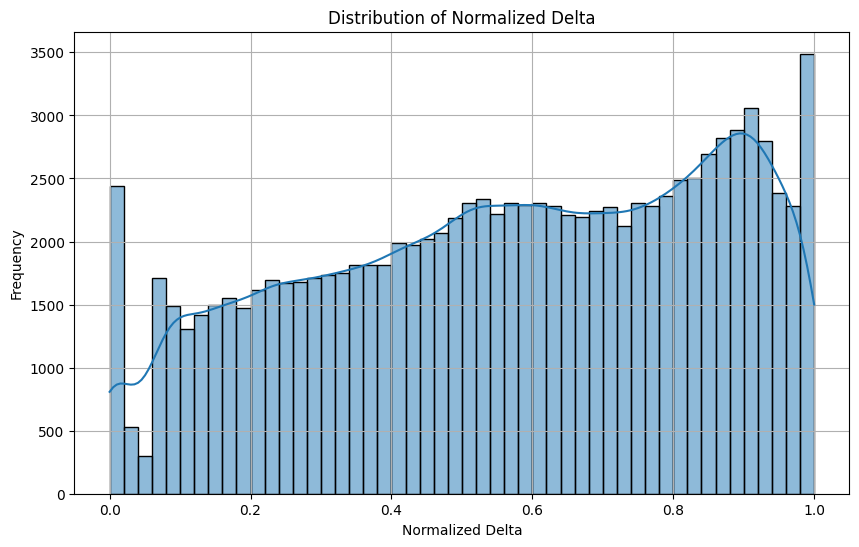

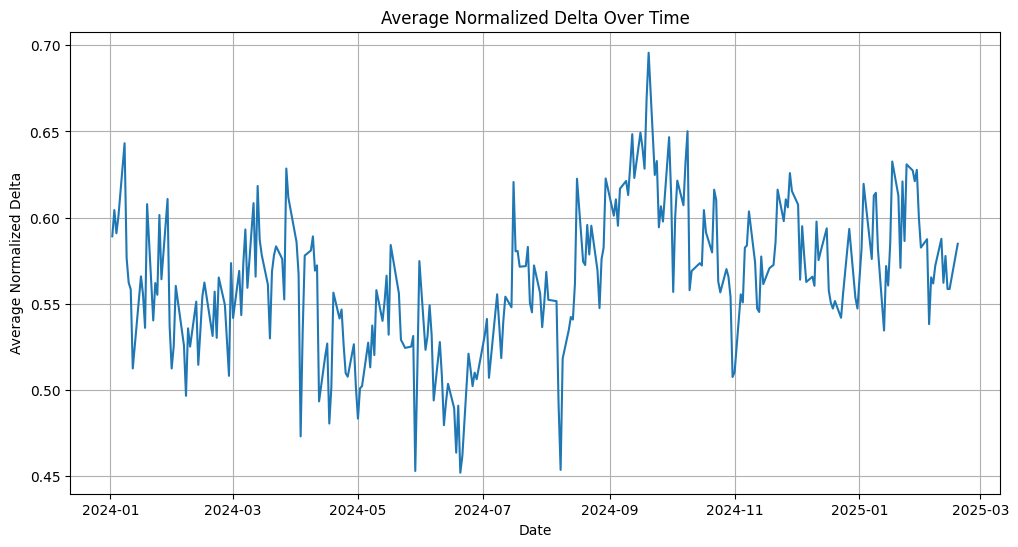

In [20]:
# Function to calculate Delta for an option using the Black-Scholes model
def calculate_delta_vectorized(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

# Calculate Delta for the options
merged['delta'] = calculate_delta_vectorized(merged['underlying_price'], merged['strike'], T, risk_free_rate, merged['implied_volatility'])

# Normalize Delta using Min-Max normalization
delta_min = merged['delta'].min()
delta_max = merged['delta'].max()
merged['delta_normalized'] = (merged['delta'] - delta_min) / (delta_max - delta_min)

# Check the first few rows of the updated DataFrame
print(merged[['underlying_price', 'strike', 'delta', 'delta_normalized']].head())



# 1. Normalized Delta vs. Implied Volatility
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged, x='implied_volatility', y='delta_normalized', hue='option_type', alpha=0.7)
plt.title('Normalized Delta vs. Implied Volatility')
plt.xlabel('Implied Volatility')
plt.ylabel('Normalized Delta')
plt.grid()
plt.show()



# 2. Distribution of Normalized Delta
plt.figure(figsize=(10, 6))
sns.histplot(merged['delta_normalized'], bins=50, kde=True)
plt.title('Distribution of Normalized Delta')
plt.xlabel('Normalized Delta')
plt.ylabel('Frequency')
plt.grid()
plt.show()



# 4. Time Series Analysis of Normalized Delta Over Time
plt.figure(figsize=(12, 6))
merged.groupby('eod_date')['delta_normalized'].mean().plot()
plt.title('Average Normalized Delta Over Time')
plt.xlabel('Date')
plt.ylabel('Average Normalized Delta')
plt.grid()
plt.show()


# Delta also represents the probability that the option will expire in-the-money. 
# For example, a call option with a delta of 0.7 has a 70% chance of ending up in-the-money.
# Call options: Delta ranges from 0 to 1. A delta of 0.5 means the option’s price will move half as much as the underlying asset. 
# For example, if the stock price increases by $1, the call option’s price will increase by $0.50.
# Put options: Delta ranges from 0 to -1. 
# A delta of -0.5 means the put option’s price will increase by $0.50 for every $1 decrease in the underlying asset.
# At-the-money options have a delta close to 0.5 for calls and -0.5 for puts.
# In-the-money options have a higher delta, closer to 1 or -1.
# Out-of-the-money options have a delta closer to 0.
